In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
WORKUNITS_CREATION_NAME = "workunits_creation"
EXP_NAME = "statistics"
RUN_FOLDER = None


In [3]:
def load_generated_workunits(file_path):
    df = pd.read_csv(file_path, sep=r"\s+", header=None, names=["group", "created"])
    df["group"] = df["group"].astype(int)
    df["created"] = df["created"].astype(int)
    df["second"] = df.groupby("group").cumcount()
    df["hour"] = (df["second"] // 7200).astype(int) * 2
    hourly = (
        df.groupby(["hour", "group"], as_index=False)["created"]
        .sum()
        .sort_values(["hour", "group"])
    )
    return hourly

def plot_generated_workunits(ax, hourly, title):
    groups = sorted(hourly["group"].unique())
    hours = sorted(hourly["hour"].unique())
    x = np.array(hours, dtype=float)
    bottom = np.zeros(len(hours), dtype=int)

    for group in groups:
        group_df = (
            hourly[hourly["group"] == group]
            .set_index("hour")
            .reindex(hours, fill_value=0)
        )
        values = group_df["created"].to_numpy()
        ax.bar(x, values, width=0.8, bottom=bottom, label=f"group {group}")
        bottom = bottom + values

    tick_step = 1 if len(hours) <= 24 else max(1, len(hours) // 24)
    ax.set_xticks(hours[::tick_step])
    ax.set_title(f"Generated workunits by time ({title})")
    ax.set_xlabel("Time, hours")
    ax.set_ylabel("Created workunits, units")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
    ax.legend(title="Task source group")


found ['statistics_1', 'statistics_2']
selected statistics_2


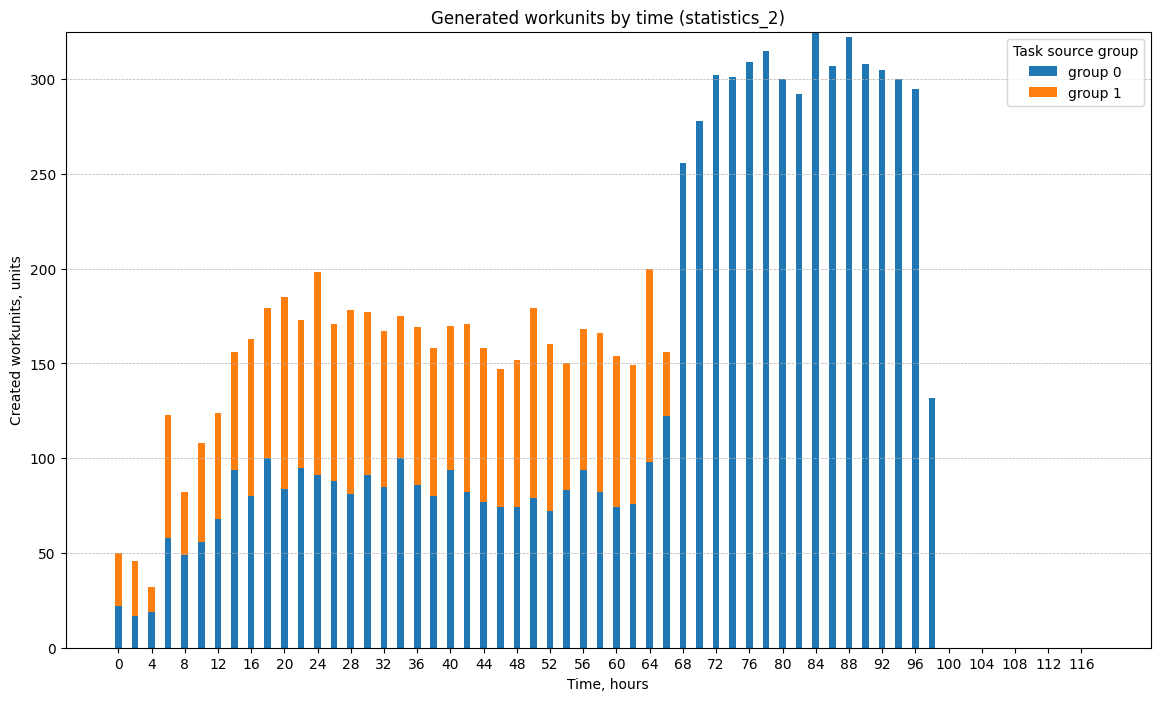

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    selected_folder = RUN_FOLDER if RUN_FOLDER is not None else folders[-1]
    print(f"found {folders}")
    print(f"selected {selected_folder}")

    if selected_folder not in folders:
        print(f"skip {selected_folder}: folder not found")
    else:
        full_path = os.path.join(STAT_PATH, selected_folder)
        workunits_creation_path = os.path.join(full_path, WORKUNITS_CREATION_NAME)

        if not os.path.exists(workunits_creation_path):
            print(f"skip {selected_folder}: {WORKUNITS_CREATION_NAME} not found")
        else:
            hourly = load_generated_workunits(workunits_creation_path)
            fig, ax = plt.subplots(figsize=(14, 8))
            plot_generated_workunits(ax, hourly, selected_folder)
            plt.show()
